# CFD Surrogate Modeling — Data Preprocessing Pipeline

**A hands-on workshop notebook**

Welcome! In this notebook you will take **raw Computational Fluid Dynamics (CFD) data**
— building geometry images and their corresponding velocity-field CSVs — and turn it into
**training-ready tensors** for a deep-learning surrogate model.

A *surrogate model* is a fast neural-network approximation of an expensive simulation.
The reference study for this workshop replaced **~1 hour of CFD per case** with a U-Net that
predicts the velocity field in **~70 milliseconds**
(Vandewiel et al., *Journal of Building Engineering* 105, 2025).

Everything we do here follows the five-stage preprocessing pipeline below. Run the next cell
to render it — we will return to this diagram at the start of every stage.

### What each stage does

| # | Stage | Goal in this notebook |
|:--:|-------|-----------------------|
| **3.1** | **Data Cleaning** | Validate every target CSV — check for missing / NaN / corrupted values. |
| **3.2** | **Architecture Selection** | Justify a **U-Net** for this image-to-image regression task. |
| **3.3** | **Feature Engineering** | Build three physics-aware input channels: **SDF**, **inlet velocity**, **flow region**. |
| **3.4** | **Train / Val / Test Split** | **Stratified 80 / 10 / 10** split by inlet-velocity group (no leakage). |
| **3.5** | **Scaling / Normalization** | Standardize / normalize using **training-set statistics only**. |

By the end you will have a `processed/` folder of standardized `.npy` inputs and matching
target CSVs, plus saved scaling statistics for inference — exactly what a training notebook needs.

---
# Section 1 — Workspace Setup

Before any preprocessing we need to (1) get the dataset onto your Google Drive, (2) mount Drive
in Colab, and (3) define a single **configuration dictionary** that holds every path the
notebook will use. Centralizing paths in one place keeps the notebook reproducible and easy to
adapt to your own folder layout.

### Step 1 — Open the dataset link

Open the public dataset folder in your browser:

**https://drive.google.com/drive/folders/1AZPb2Zbqrp0r-uLBgYJIoj3oRtbXV-qg?usp=sharing**

You should see a folder containing `inputs/` (building-geometry images), `targets/`
(velocity-field CSVs), and `velmap.csv` (a table mapping each case ID to its inlet velocity).

### Step 2 — Add a shortcut to *your* Google Drive

You cannot mount someone else's shared folder directly, so add a shortcut:

1. In the shared folder view, click the folder name at the top → **Organize** → **Add shortcut to Drive**
   *(older UI: right-click the folder → **Add shortcut to Drive**).*
2. Choose a location in **My Drive** (the root is fine) and click **Add shortcut**.

> 📸 *Placeholder — your screen should now show the dataset folder as a shortcut inside **My Drive**.*

That's it — the shortcut behaves like a normal folder once Drive is mounted.

### Step 3 — Mount Google Drive in Colab

Run the next cell and follow the authorization prompt. After mounting, your Drive lives under
`/content/drive/MyDrive/`.

In [87]:
# ── Mount Google Drive (Colab) ────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
    DRIVE_ROOT = "/content/drive/MyDrive"
    print("Google Drive mounted at /content/drive")
except Exception as e:
    # Lets the notebook also run outside Colab (e.g. local testing).
    IN_COLAB = False
    DRIVE_ROOT = "."
    print("Not running in Colab — set DATASET_DIR manually in the next cell.")
    print(f"   ({type(e).__name__}: {e})")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at /content/drive


### Step 4 — Define the configuration dictionary


All downstream code reads paths **only** from the `CONFIG` dictionary — never hard-coded
strings — so you can relocate the project by editing this one cell.

In [88]:
from pathlib import Path

DATASET_DIR = "/content/drive/MyDrive/CFD-WORKSHOP-RAW-DATA"
DATASET_DIR = Path(DATASET_DIR)
print("Dataset root :", DATASET_DIR)
VELMAP_PATH = "/content/drive/MyDrive/CFD-WORKSHOP-RAW-DATA/velmap.csv"

# ── Workspace (where WE write outputs) ────────────────────────────────────────
# Local Colab storage is much faster for many small .npy files than Drive.
WORKSPACE = Path("/content/cfd_workshop")

# ── The single source of truth for every path ────────────────────────────────
CONFIG = {
    "workspace":   WORKSPACE,
    "raw_inputs":  DATASET_DIR / "inputs",     # building-geometry images
    "raw_targets": DATASET_DIR / "targets",    # velocity-field CSVs
    "velmap":      VELMAP_PATH,                 # case_id -> inlet velocity
    "processed":   WORKSPACE / "processed",     # engineered + scaled outputs
    "models":      WORKSPACE / "models",        # scalers / saved statistics
    "logs":        WORKSPACE / "logs",          # run logs
}

print("\nCONFIG paths:")
for k, v in CONFIG.items():
    print(f"  {k:>11} : {v}")

Dataset root : /content/drive/MyDrive/CFD-WORKSHOP-RAW-DATA

CONFIG paths:
    workspace : /content/cfd_workshop
   raw_inputs : /content/drive/MyDrive/CFD-WORKSHOP-RAW-DATA/inputs
  raw_targets : /content/drive/MyDrive/CFD-WORKSHOP-RAW-DATA/targets
       velmap : /content/drive/MyDrive/CFD-WORKSHOP-RAW-DATA/velmap.csv
    processed : /content/cfd_workshop/processed
       models : /content/cfd_workshop/models
         logs : /content/cfd_workshop/logs


---
# Section 2 — Workspace Directory Creation

We now create the output directories (`processed/`, `models/`, `logs/`) inside your workspace.
The raw `inputs/` and `targets/` folders live in your Drive shortcut and are **read-only** to us —
we never modify the source data.

In [89]:
import shutil

# ── Create output directories ──────────────────────────────────────────────────
# If a processed/ folder already exists from a previous run, delete it completely
# so we always start with a clean slate — no leftover files from old runs.
if CONFIG["processed"].exists():
    shutil.rmtree(CONFIG["processed"])
    print("Removed existing processed/ folder.")

for key in ("workspace", "processed", "models", "logs"):
    CONFIG[key].mkdir(parents=True, exist_ok=True)

# One inputs/ + targets/ sub-folder per split so the training notebook can
# point directly at a folder without any filename-based filtering.
for split in ("train", "val", "test"):
    (CONFIG["processed"] / split / "inputs").mkdir(parents=True, exist_ok=True)
    (CONFIG["processed"] / split / "targets").mkdir(parents=True, exist_ok=True)

print("Workspace directory tree:")
print(f"  {CONFIG['workspace']}/")
print(f"  ├── processed/")
print(f"  │   ├── train/")
print(f"  │   │   ├── inputs/")
print(f"  │   │   └── targets/")
print(f"  │   ├── val/")
print(f"  │   │   ├── inputs/")
print(f"  │   │   └── targets/")
print(f"  │   └── test/")
print(f"  │       ├── inputs/")
print(f"  │       └── targets/")
print(f"  ├── models/")
print(f"  └── logs/")
print("\nAll output directories ready.")

Removed existing processed/ folder.
Workspace directory tree:
  /content/cfd_workshop/
  ├── processed/
  │   ├── train/
  │   │   ├── inputs/
  │   │   └── targets/
  │   ├── val/
  │   │   ├── inputs/
  │   │   └── targets/
  │   └── test/
  │       ├── inputs/
  │       └── targets/
  ├── models/
  └── logs/

All output directories ready.


---
# Section 3 — Load Dataset

Let's inventory the raw data **before touching it**. We match cases by filename stem: an input
`inputs/<id>.<ext>` is paired with a target `targets/<id>.csv`, and `<id>` must appear in
`velmap.csv`. The summary table below tells us how many files we have, what file types they are,
and how many cases are *complete* (input + target + velocity all present).

In [91]:
import numpy as np
import pandas as pd
from collections import Counter

# ── Shared imports for the whole notebook ─────────────────────────────────────
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from PIL import Image
from scipy.ndimage import distance_transform_edt, binary_dilation
import random, warnings
warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [92]:
# ── Inventory helper ──────────────────────────────────────────────────────────
def list_files(folder):
    folder = Path(folder)
    return sorted([f for f in folder.iterdir() if f.is_file()]) if folder.is_dir() else []

input_files  = list_files(CONFIG["raw_inputs"])
target_files = list_files(CONFIG["raw_targets"])

def ext_counts(files):
    return Counter(f.suffix.lower() for f in files)

# Load the velocity map (case_id -> inlet velocity).
velmap_df = pd.read_csv(CONFIG["velmap"])

velmap = dict(zip(velmap_df["im_id"].astype(int), velmap_df["velocity"].astype(float)))

# Match cases by filename stem.
def stem_to_int(f):
    try:    return int(f.stem)
    except ValueError: return None

input_ids  = {stem_to_int(f): f for f in input_files  if stem_to_int(f) is not None}
target_ids = {stem_to_int(f): f for f in target_files if stem_to_int(f) is not None}
complete_ids = sorted(set(input_ids) & set(target_ids) & set(velmap))

print(f"Loaded velmap with {len(velmap)} entries "
      f"(id column = im_id, velocity column = velocity).")
print(f"Complete cases (input + target + velocity) : {len(complete_ids)}")

Loaded velmap with 1458 entries (id column = im_id, velocity column = velocity).
Complete cases (input + target + velocity) : 296


In [93]:
# ── Clean dataset summary table ───────────────────────────────────────────────
summary = pd.DataFrame(
    [
        {
            "Folder": "inputs/",
            "Num files": len(input_files),
            "File types": ", ".join(f"{k} ({v})" for k, v in ext_counts(input_files).items()) or "—",
            "Content": "Building geometry images",
        },
        {
            "Folder": "targets/",
            "Num files": len(target_files),
            "File types": ", ".join(f"{k} ({v})" for k, v in ext_counts(target_files).items()) or "—",
            "Content": "Velocity-field point clouds (CSV)",
        },
        {
            "Folder": "velmap.csv",
            "Num files": 1,
            "File types": ".csv (1)",
            "Content": f"{len(velmap)} case_id -> inlet velocity rows",
        },
    ]
)
print("Velocity groups present:",
      sorted({velmap[c] for c in complete_ids}))
summary

Velocity groups present: [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]


,Folder,Num files,File types,Content
0,inputs/,296,.png (296),Building geometry images
1,targets/,296,.csv (296),Velocity-field point clouds (CSV)
2,velmap.csv,1,.csv (1),1458 case_id -> inlet velocity rows


---
# Section 4 — Exploratory Visualization

Always *look* at your data before processing it. We randomly sample **3 complete cases** and,
for each, display the **input geometry** alongside its **target velocity field**.

#### The custom velocity colormap

The reference study renders every velocity field with a fixed 25-color map spanning
**0 → 13 m/s**. Using the same map everywhere lets us compare cases at a glance. We define it
once here and reuse it for all velocity-field plots throughout the notebook.

In [95]:
# ── Custom velocity colormap (0 -> 13 m/s) ────────────────────────────────────
hex_col = ['#0000ff', '#0068ff', '#0093ff', '#00b4ff', '#00d0ff', '#00e9ff', '#00ffff', '#00ffe9',
           '#00ffd0', '#00ffb4', '#00ff93', '#00ff68', '#00ff00', '#68ff00', '#93ff00', '#b4ff00',
           '#d0ff00', '#e9ff00', '#ffff00', '#ffe900', '#ffd000', '#ffb400', '#ff9300', '#ff6800', '#ff0000']

velocity_cmap = matplotlib.colors.ListedColormap(hex_col)

boundaries = [0.0, 0.52, 1.04, 1.56, 2.08, 2.6, 3.12, 3.64, 4.16, 4.68, 5.2, 5.72,
              6.24, 6.76, 7.28, 7.8, 8.32, 8.84, 9.36, 9.88, 10.4, 10.92, 11.44, 11.96, 12.48, 13.0]
velocity_norm = matplotlib.colors.BoundaryNorm(boundaries, velocity_cmap.N)

print("Custom velocity colormap ready: 25 colors over 0–13 m/s.")

Custom velocity colormap ready: 25 colors over 0–13 m/s.


#### Loading helpers

We define two small, reusable loaders (adapted from the reference preprocessing notebook):

- `load_input_image` — opens a geometry image, resizes to a square grid, normalizes to `[0, 1]`,
  and flips it vertically so **row 0 = physical bottom**, matching the CSV coordinate convention.
- `load_target_grid` — reads a target CSV of scattered `(x, y, velocity)` points and bins them onto
  the same square grid, producing a 2-D velocity-magnitude image.

`IMG_SIZE = 256` matches the 256 × 256 Cartesian grid used in the reference paper.

In [97]:
# ── Grid resolution ───────────────────────────────────────────────────────────
IMG_SIZE = 128

def load_input_image(path, size=IMG_SIZE):
    """Load a geometry image -> float32 array in [0,1], shape (size, size).
    Convention: high values (~1) = open fluid domain, low values (~0) = solid walls."""
    img = Image.open(path)
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.flipud(arr)            # row 0 = physical bottom (match CSV y-up)
    return arr

def load_target_grid(path, size=IMG_SIZE):
    """Read a target CSV of (x, y, velocity) points and bin onto a size x size grid."""
    # Read the CSV file. The fallback handles edge cases where the default parser fails.
    try:
        df = pd.read_csv(path, on_bad_lines="skip")
    except Exception:
        df = pd.read_csv(path, engine="python", on_bad_lines="skip")

    # Select only the three columns we need, convert everything to numbers,
    # and drop any row that couldn't be parsed (e.g. header duplicates, text artifacts).
    df = df[["x", "y", "velocity"]].apply(pd.to_numeric, errors="coerce").dropna()

    # Pull out the coordinate and velocity arrays for easier indexing below.
    x, y, v = df["x"].values, df["y"].values, df["velocity"].values

    # Divide the x and y ranges into `size` equal-width bins.
    # This creates size+1 boundary values (the edges between bins).
    # Think of it as a ruler laid across the physical domain — each gap is one grid cell.
    x_edges = np.linspace(x.min(), x.max(), size + 1)
    y_edges = np.linspace(y.min(), y.max(), size + 1)

    # Find which bin each scatter point falls into.
    # np.digitize returns a 1-based index, so we subtract 1 to make it 0-based.
    # np.clip ensures points that land exactly on the far edge stay inside the grid
    # rather than going out of bounds.
    xi = np.clip(np.digitize(x, x_edges) - 1, 0, size - 1)
    yi = np.clip(np.digitize(y, y_edges) - 1, 0, size - 1)

    # Create a blank size×size grid, then place each velocity value at its (row, col) cell.
    # Because there is exactly one scatter point per cell (16384 points for a 128×128 grid),
    # every cell gets filled with no collisions.
    grid = np.zeros((size, size), dtype=np.float32)
    grid[yi, xi] = v
    return grid

Sampled cases: [58, 13, 142]


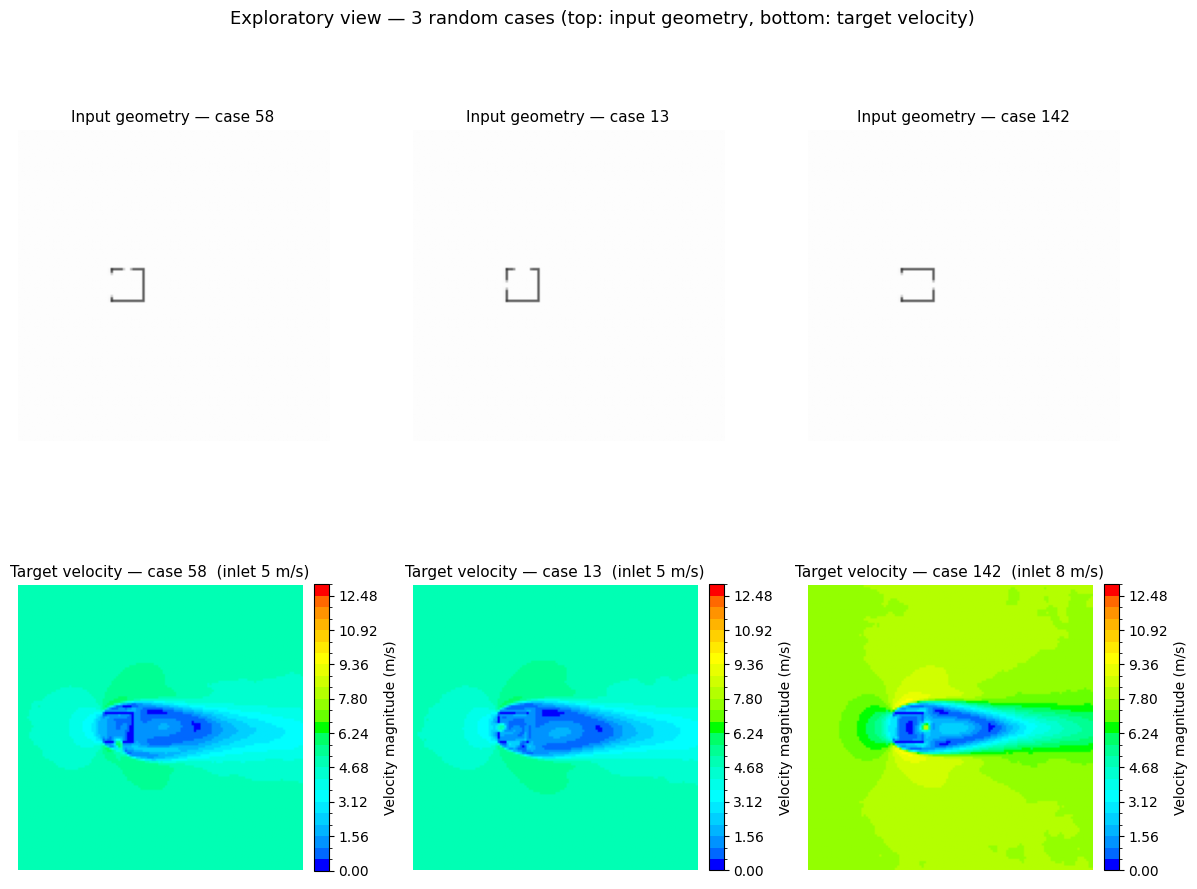

In [98]:
# ── Sample 3 random cases and visualize inputs + targets ──────────────────────
import matplotlib.pyplot as plt

sample_ids = random.sample(complete_ids, 3)
print("Sampled cases:", sample_ids)

fig, axes = plt.subplots(2, 3, figsize=(12, 10))

for j, cid in enumerate(sample_ids):
    # Row 0: input geometry
    geo = load_input_image(input_ids[cid])
    axes[0, j].imshow(geo, origin="lower", cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(f"Input geometry — case {cid}", fontsize=11)
    axes[0, j].axis("off")

    # Row 1: target velocity field (custom velocity colormap)
    vel = load_target_grid(target_ids[cid])
    im = axes[1, j].imshow(vel, origin="lower", cmap=velocity_cmap, norm=velocity_norm)
    axes[1, j].set_title(f"Target velocity — case {cid}  (inlet {velmap[cid]:.0f} m/s)", fontsize=11)
    axes[1, j].axis("off")
    plt.colorbar(im, ax=axes[1, j], fraction=0.046, pad=0.04, label="Velocity magnitude (m/s)")

fig.suptitle("Exploratory view — 3 random cases (top: input geometry, bottom: target velocity)",
             fontsize=13, y=0.98)
plt.tight_layout()
plt.show()

> **Note on the input display.** Geometry images are essentially binary (walls vs. open domain),
> so we show them in grayscale for clarity. The custom *velocity* colormap is reserved for
> velocity fields — the targets here and the model predictions later. If your `inputs/` folder
> happens to store rendered velocity contours instead of geometry, simply pass
> `cmap=velocity_cmap, norm=velocity_norm` to the input `imshow` call above.

---
# Section 5 — Data Cleaning  *(Pipeline stage 3.1)*

Garbage in, garbage out. Before engineering any features we validate **every target CSV** for
missing values, NaNs, and corrupted (non-numeric / empty) entries. We produce per-file summary
statistics and an overall pass/fail report so we know exactly which cases are safe to use.

In [100]:
def validate_target_csv(path):
    """Check a target CSV for NaN values. Returns the case id and NaN count."""
    df = pd.read_csv(path, on_bad_lines="skip")
    df = df[["x", "y", "velocity"]].apply(pd.to_numeric, errors="coerce")
    n_nan = int(df.isna().sum().sum())
    return {"case": int(Path(path).stem), "n_nan": n_nan}

reports = []
total = len(complete_ids)
for i, cid in enumerate(complete_ids, 1):
    reports.append(validate_target_csv(target_ids[cid]))
    print(f"\rValidating CSVs: {i}/{total}", end="", flush=True)
print()  # move to next line when done

# Print a summary: flag any files that contain NaNs, or confirm all are clean.
files_with_nan = [r for r in reports if r["n_nan"] > 0]
if files_with_nan:
    print(f"NaN values detected in {len(files_with_nan)} / {len(reports)} file(s):")
    for r in files_with_nan:
        print(f"  case {r['case']}: {r['n_nan']} NaN cell(s)")
else:
    print(f"All good to go — no NaN values found across all {len(reports)} CSVs.")

# All complete cases are usable downstream; any NaN rows are dropped during loading.

Validating CSVs: 296/296
All good to go — no NaN values found across all 296 CSVs.


---
# Section 6 — Architecture Selection  *(Pipeline stage 3.2)*

## Why U-Net?

Choosing an architecture starts with the **nature of the task**, not personal preference. Our task is:

- **Image-to-image prediction.** The input is a 2-D field (geometry + boundary information) and the
  output is another 2-D field (the velocity magnitude at every pixel). Input and output share the
  same spatial grid.
- **Dense spatial regression.** We predict a continuous value at *every* pixel — not a single
  number and not a class label. Errors are local: a wrong value near an opening must not smear the
  whole field.
- **Geometry-dependent.** The flow is governed by *where* the walls, openings, inlet, and outlet
  are. The model must respect fine geometric detail (corners, opening widths) while also reasoning
  about large-scale patterns (jets, wakes, recirculation).

### U-Net fits this task

The **U-Net** is an encoder–decoder convolutional network, originally introduced for biomedical
image segmentation (Ronneberger, Fischer & Brox, 2015). It is well suited here because:

- **Encoder–decoder structure.** The encoder (contracting path) compresses the input into abstract,
  multi-scale features; the decoder (expanding path) reconstructs a full-resolution output. This is
  exactly the "field → field" shape we need.
- **Skip connections.** Direct links from each encoder level to the matching decoder level carry
  **fine spatial detail** across the bottleneck. Without them, downsampling would blur the precise
  locations of walls and openings.
- **Preserves spatial information.** Because it is fully convolutional with skip connections, the
  U-Net keeps the *where* — every output pixel stays aligned with the corresponding input pixel.
- **Captures local *and* global features.** Deep encoder levels see the global flow context (overall
  jet/wake structure) while shallow skip features retain local geometry — both matter for accurate
  flow prediction.

### Why not a plain MLP?

A fully-connected multilayer perceptron (MLP) is a poor fit:

- **Loss of spatial structure.** Flattening a 256 × 256 grid into one long vector throws away the
  2-D neighborhood relationships that define a flow field.
- **Poor parameter efficiency.** A dense layer over 65,536 pixels needs an enormous, unshared weight
  matrix. Convolutions share weights across the image, learning far more from far less data.
- **Difficulty learning geometry–flow relationships.** With no built-in notion of locality or
  translation, an MLP struggles to connect a wall's position to the jet it produces.

> The reference study goes one step further and adds a **spatial-attention** mechanism on the skip
> connections so the network emphasizes critical flow regions (openings, jets). For this
> preprocessing workshop, the key takeaway is that the **U-Net backbone** is the right family for
> dense, geometry-driven, image-to-image regression.

The cell below renders a schematic U-Net (encoder → bottleneck → decoder with skip connections)
so the structure is concrete.

---
# Section 7 — Feature Engineering  *(Pipeline stage 3.3)*

## The physics motivation

A raw binary geometry image tells the network *where the walls are*, but a CFD solver uses far
more information to compute a flow field. **Feature engineering** injects that physical prior
knowledge directly into the model inputs so the network does not have to rediscover physics from
scratch — improving accuracy and generalization, especially with limited data.

Following the reference study, we give the model explicit information about:

- **Geometry.** The shape and location of the building walls determine where flow separates,
  accelerates, and recirculates. We encode this as a **Signed Distance Function (SDF)** rather than
  a raw binary mask, because the SDF carries *global* distance-to-boundary information at every pixel.
- **Inlet velocity.** The same geometry produces very different fields at 2 m/s versus 10 m/s. The
  model must know the **flow magnitude / scale**, so we provide an inlet-velocity channel.
- **Flow regions / boundary conditions.** CFD solutions are driven by boundary conditions — inlet,
  outlet, walls, domain edges. A **multi-class region map** makes these explicit so the network
  knows *what kind* of physics applies where.

These three engineered channels — **SDF, inlet velocity, flow region** — become the model's input
tensor of shape `(3, 256, 256)`. We build each one below, explaining the reasoning first and then
implementing a clean, reusable function (reusing the reference notebook's implementations where
appropriate).

## Feature Channel 1 — Signed Distance Function (SDF)

### What the SDF represents

For every pixel, the SDF stores the **distance to the nearest wall boundary**, with a **sign**
encoding which side of the boundary the pixel is on:

$$
\mathrm{SDF}(i,j) =
\begin{cases}
\;\;\;\min_{(i',j') \in \partial\Omega} \big\lVert (i,j) - (i',j') \big\rVert & (i,j) \notin \Omega \quad\text{(in the fluid)}\\[4pt]
\;\;\;0 & (i,j) \in \partial\Omega \quad\text{(on the boundary)}\\[4pt]
-\min_{(i',j') \in \partial\Omega} \big\lVert (i,j) - (i',j') \big\rVert & (i,j) \in \Omega \quad\text{(inside the wall)}
\end{cases}
$$

where $\Omega$ is the solid object (building walls) and $\partial\Omega$ is its boundary.
By convention here the SDF is **positive in the fluid, zero on the wall surface, and negative
inside the walls**.

### Why it beats a binary mask

A binary mask only says "wall (0) or not-wall (1)" — purely *local* information. The SDF instead
gives a smooth, *global* field: every pixel knows **how far** it is from the nearest surface and
**which side** it is on. This distance-to-boundary signal is exactly the kind of geometric context
that governs flow behavior — boundary layers, jet spreading, and wake length all scale with distance
from surfaces — so the network learns the geometry–flow relationship far more easily. (Guo et al.,
2016, introduced SDFs for CNN flow approximation for this reason.)

In [101]:
# ── Channel 1: Signed Distance Function (reused from the reference notebook) ──
# ── Channel 1: Signed Distance Function (reused from the reference notebook) ──
def compute_sdf(geo, size=IMG_SIZE):
    """Signed distance function from a geometry image.
    Positive in fluid, negative inside walls, ~0 on the boundary.
    Normalized by the grid diagonal so values fall in roughly [-1, 1]."""

    # Step 1: Convert the grayscale geometry image into a binary wall mask.
    # Pixel values below 0.5 are treated as solid walls (1), everything else is fluid (0).
    # np.uint8 is used because distance_transform_edt expects an integer array.
    solid = (geo < 0.5).astype(np.uint8)

    # Step 2: For every wall pixel, compute its distance to the nearest fluid pixel.
    # distance_transform_edt measures the Euclidean distance from each foreground pixel (1)
    # to the nearest background pixel (0). Here foreground = wall, background = fluid,
    # so the result is positive inside the wall and zero everywhere else.
    dist_to_fluid = distance_transform_edt(solid).astype(np.float32)

    # Step 3: For every fluid pixel, compute its distance to the nearest wall pixel.
    # We invert the mask (1 - solid) so now foreground = fluid, background = wall.
    # The result is positive inside the fluid domain and zero on/inside walls.
    dist_to_solid = distance_transform_edt(1 - solid).astype(np.float32)

    # Step 4: Combine the two distance fields into a single signed field.
    # - Fluid pixels  → dist_to_solid > 0, dist_to_fluid = 0  → sdf > 0  (positive)
    # - Wall pixels   → dist_to_solid = 0, dist_to_fluid > 0  → sdf < 0  (negative)
    # - Boundary      → both ≈ 0                              → sdf ≈ 0
    sdf = dist_to_solid - dist_to_fluid

    # Step 5: Normalize by the grid diagonal.
    # The diagonal is the longest possible straight-line distance inside a size×size grid
    # (corner to corner = size * sqrt(2)). Any pixel distance in the grid is at most this
    # value, so dividing by it maps the SDF into roughly [-1, 1].
    #
    # Why normalize at all?
    # Raw pixel distances can be in the range [0, ~180] for a 128×128 grid, while the
    # inlet-velocity channel is in [2, 10] m/s and the region channel in [1, 6].
    # If one channel has values 100× larger than another, the network's gradient updates
    # will be dominated by the large channel, making training unstable and biased.
    # Normalizing all channels to a comparable scale (~[-1, 1] or [0, 1]) prevents this.
    #
    # Why the diagonal specifically (and not, say, the side length `size`)?
    # A pixel in one corner of the grid can be at most `size * sqrt(2)` pixels away from
    # a wall in the opposite corner. Using the true geometric maximum guarantees that no
    # normalized SDF value ever exceeds ±1, regardless of where walls are placed.
    diagonal = float(size) * np.sqrt(2.0)
    return (sdf / diagonal).astype(np.float32)

print("compute_sdf() defined.")

compute_sdf() defined.


## Feature Channel 2 — Inlet Velocity

### What the channel represents

This channel encodes the **inlet wind speed** for the case (from `velmap.csv`), broadcast across the
domain so the magnitude information is available at every pixel.

### Why inlet velocity is critical

The geometry alone is ambiguous: the *same* building produces a gentle field at 2 m/s and a strong,
jet-dominated field at 10 m/s. The reference dataset is built by re-scaling each simulated case to
many inlet speeds (2–10 m/s), so **inlet velocity is the single most important scalar driving the
output magnitude**. Providing it explicitly lets the network condition its prediction on the correct
flow regime instead of guessing the scale.

In [102]:
# ── Channel 2: Inlet velocity────────────
def build_inlet_velocity_channel(case_id, size=IMG_SIZE):
    """Broadcast the case's inlet speed (m/s) across the whole grid."""
    v_in = float(velmap[case_id])
    return np.full((size, size), v_in, dtype=np.float32)

print("build_inlet_velocity_channel() defined.")

build_inlet_velocity_channel() defined.


## Feature Channel 3 — Flow Region Labeling

### What regions are encoded

We assign each pixel an integer label identifying the **type of region / boundary condition** it
belongs to, mirroring the multi-class scheme in the reference paper (Fig. 11):

| Label | Region |
|:-----:|--------|
| 1 | Building wall (the solid object) |
| 2 | Upper & lower domain boundaries (top/bottom rows) |
| 3 | Inlet boundary (left column) |
| 4 | Outlet boundary (right column) |
| 5 | Fluid (interior + exterior open flow) |

### Why region awareness helps

In CFD, the solution is *defined* by its boundary conditions — flow enters at the inlet, leaves at
the outlet, sticks to walls (no-slip), and passes freely through the open domain. Telling the model
**which physics applies where** removes ambiguity that a single geometry image cannot resolve: a
pixel touching a wall behaves very differently from one in open fluid even if they look similar
locally. The reference study found that adding these boundary-condition features improved the
model's ability to capture critical flow behavior near openings and walls.

In [104]:
# ── Channel 3: Multi-class flow-region labels (after reference Fig. 11) ───────
def assign_flow_regions(geo_128):
    H, W      = geo_128.shape
    label_map = np.zeros((H, W), dtype=np.int8)

    label_map[geo_128 < 0.5] = 1   # building walls
    label_map[0,   1:W-1]    = 2   # bottom boundary row
    label_map[H-1, 1:W-1]    = 2   # top boundary row
    label_map[:, 0]          = 3   # inlet (left column)
    label_map[:, W-1]        = 4   # outlet (right column)
    label_map[label_map == 0] = 5  # fluid (everything remaining)

    return label_map

## Feature Engineering Validation

Let's verify all three channels on a single random case. We display the **SDF**, **inlet-velocity**,
and **flow-region** channels side-by-side with consistent, publication-quality formatting,
appropriate colorbars, and a legend for the discrete region labels.

Validation case 127  (inlet 2 m/s)   input tensor (3, 128, 128)


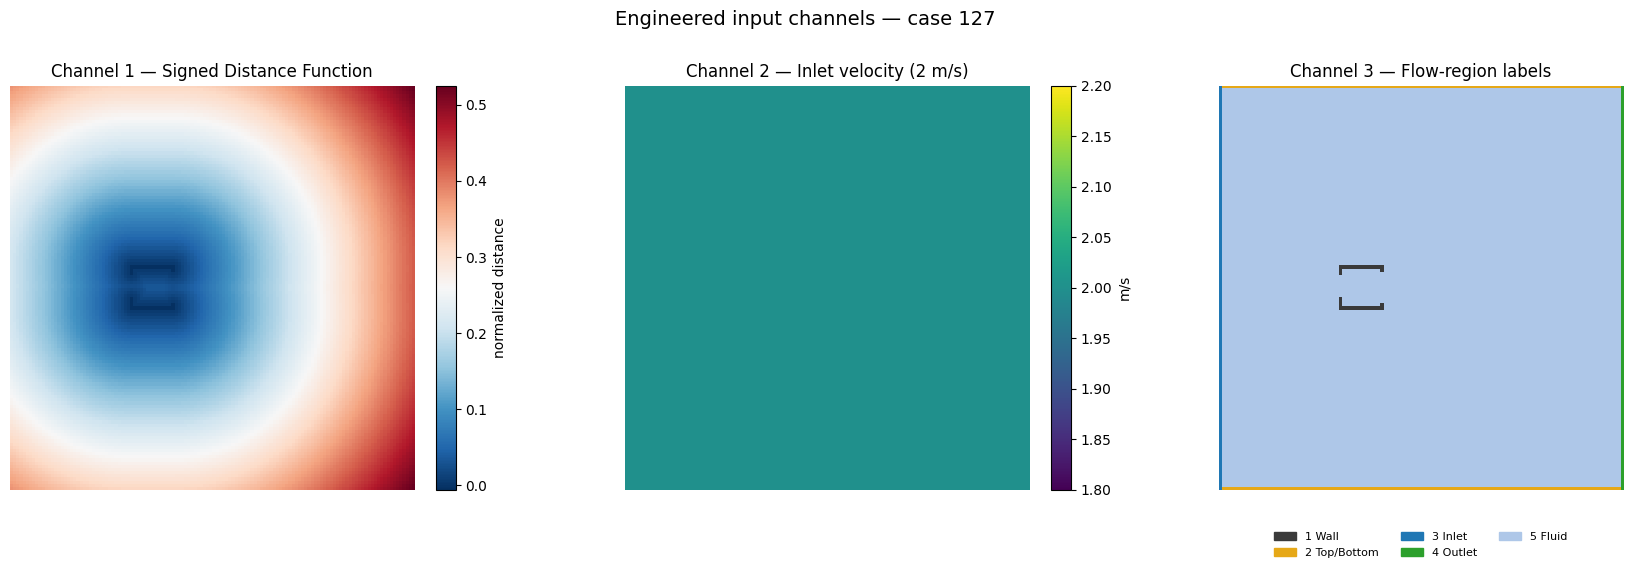

In [105]:
# ── Assemble the 3-channel input and visualize ────────────────────────────────
def build_input_channels(case_id, geo=None):
    """Stack the three engineered channels -> (3, IMG_SIZE, IMG_SIZE) float32:
        [0] SDF            ~[-1, 1]
        [1] Inlet velocity  raw m/s (constant field)
        [2] Flow region     integer labels {1..6}"""
    if geo is None:
        geo = load_input_image(input_ids[case_id])
    ch0 = compute_sdf(geo)
    ch1 = build_inlet_velocity_channel(case_id)
    ch2 = assign_flow_regions(geo).astype(np.float32)
    return np.stack([ch0, ch1, ch2], axis=0)

# Region colormap + legend
REGION_INFO = {1: ("#3a3a3a", "Wall"), 2: ("#e6a817", "Top/Bottom"),
               3: ("#1f77b4", "Inlet"), 4: ("#2ca02c", "Outlet"),
               5: ("#aec7e8", "Fluid")}
region_cmap = mcolors.ListedColormap([REGION_INFO[k][0] for k in sorted(REGION_INFO)])
region_norm = mcolors.BoundaryNorm([0.5,1.5,2.5,3.5,4.5,5.5], region_cmap.N)
region_patches = [mpatches.Patch(color=REGION_INFO[k][0], label=f"{k} {REGION_INFO[k][1]}")
                  for k in sorted(REGION_INFO)]

vcid = random.choice(complete_ids)
X = build_input_channels(vcid)
print(f"Validation case {vcid}  (inlet {velmap[vcid]:.0f} m/s)   input tensor {X.shape}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

im0 = axes[0].imshow(X[0], origin="lower", cmap="RdBu_r")
axes[0].set_title("Channel 1 — Signed Distance Function", fontsize=12)
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="normalized distance")

im1 = axes[1].imshow(X[1], origin="lower", cmap="viridis")
axes[1].set_title(f"Channel 2 — Inlet velocity ({velmap[vcid]:.0f} m/s)", fontsize=12)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="m/s")

axes[2].imshow(X[2], origin="lower", cmap=region_cmap, norm=region_norm)
axes[2].set_title("Channel 3 — Flow-region labels", fontsize=12)
axes[2].legend(handles=region_patches, loc="upper center",
               bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8, frameon=False)

for ax in axes: ax.axis("off")
fig.suptitle(f"Engineered input channels — case {vcid}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Data Augmentation  *(training set only)*

To enlarge the limited training set without running more CFD, we synthesize new **physically valid**
cases by mirroring existing ones. We use two geometric transforms:

- **Horizontal flip** (left–right mirror)
- **Vertical flip** (up–down mirror)

**Consistency is the whole point.** Each transform is applied **identically to all three input
channels *and* the target** with a single `np.flip`, so every input pixel stays aligned with its
target pixel. Because the channels are flipped together, the engineered features remain coherent:

- The **SDF** mirrors with the geometry, so distances still measure to the (mirrored) walls.
- The **inlet-velocity** channel is a constant field, so flipping leaves it unchanged.
- The **flow-region** channel mirrors too, so the inlet/outlet markers move to the correct sides
  automatically. Under a horizontal flip the inlet edge (left) becomes the right edge — which is
  exactly consistent with the flipped velocity field, where the approach flow now enters from the
  right. No manual relabeling is needed; an identical flip *is* the physically consistent operation.

A vertical flip mirrors top↔bottom and leaves the inlet/outlet sides unchanged (it does not alter
the wind direction), so it likewise produces a valid mirrored scenario.

> **Where this runs in the pipeline:** augmentation is integrated in Section 10 and applied **only to
> the training set**, *after* scaling — never to validation or test. The functions below operate on
> any `(C, H, W)` input tensor and `(H, W)` target, so they work identically on scaled or raw arrays.

In [106]:
# ── Augmentation transforms (apply identically to inputs AND target) ──────────
def augment_hflip(X, y):
    """Horizontal (left-right) mirror of every input channel and the target.
    axis=-1 is the width (x) axis, shared by X (C,H,W) and y (H,W)."""
    return np.flip(X, axis=-1).copy(), np.flip(y, axis=-1).copy()

def augment_vflip(X, y):
    """Vertical (up-down) mirror of every input channel and the target.
    axis=-2 is the height (y) axis, shared by X (C,H,W) and y (H,W)."""
    return np.flip(X, axis=-2).copy(), np.flip(y, axis=-2).copy()

print("augment_hflip() and augment_vflip() defined.")

augment_hflip() and augment_vflip() defined.


### Test & visualize the augmentation

Using the **same sample case** as the feature-engineering figure above, we show the original
channels and target, then their horizontally- and vertically-flipped versions, side-by-side. Each
row is one variant; each column is one channel (plus the target). Confirm that inputs and target
flip *together* in every row.

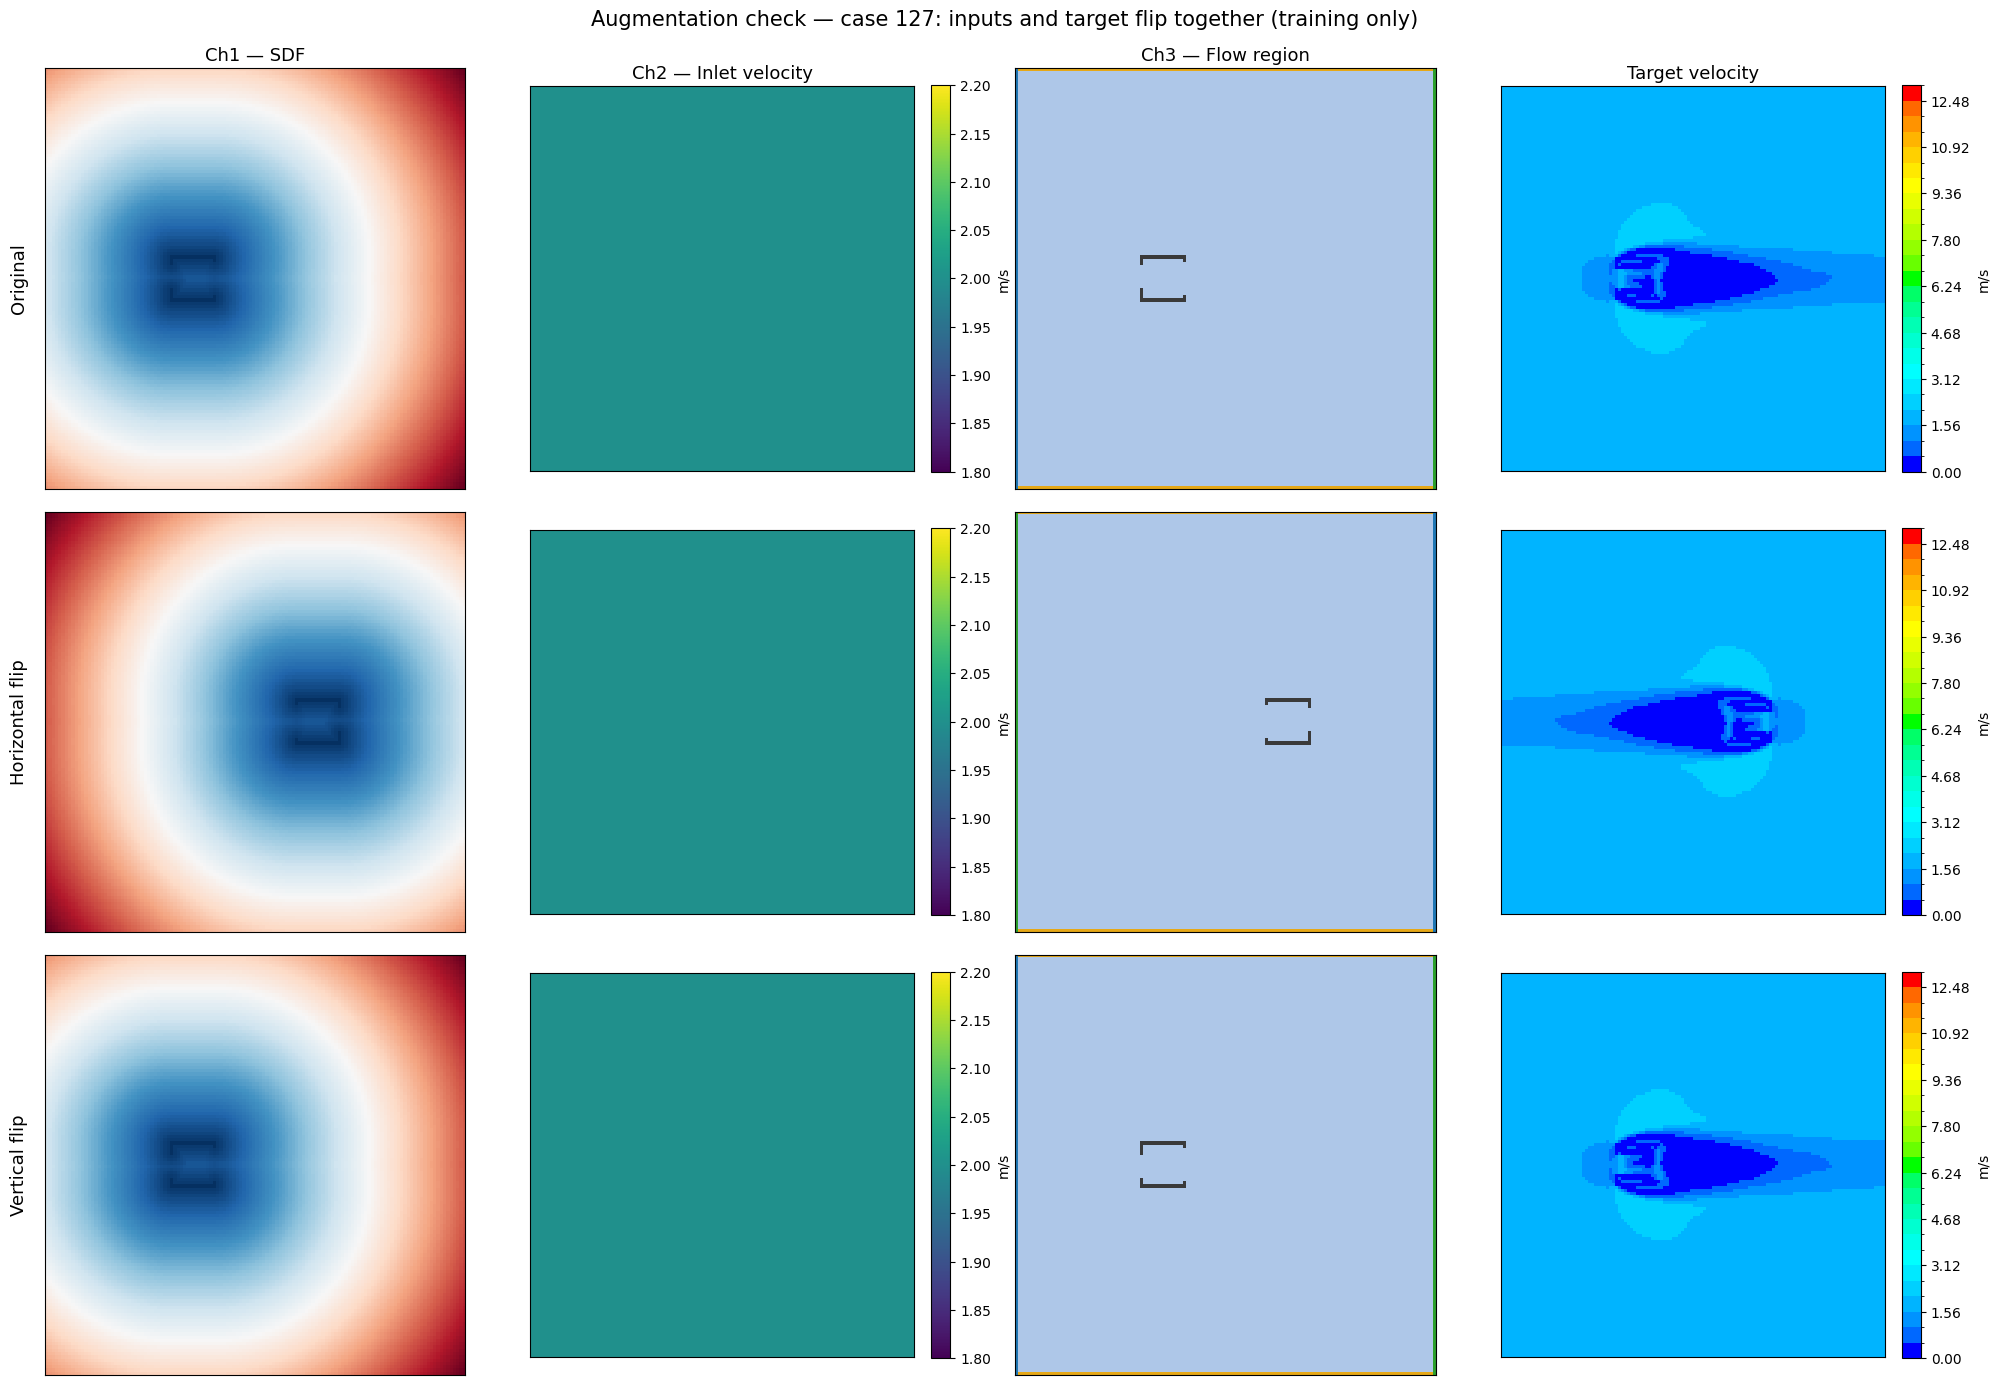

In [107]:
# ── Visualize original vs horizontal-flip vs vertical-flip (same sample) ──────
y_demo = load_target_grid(target_ids[vcid])          # raw velocity grid for the sample case

variants = [
    ("Original",        X,                       y_demo),
    ("Horizontal flip", *augment_hflip(X, y_demo)),
    ("Vertical flip",   *augment_vflip(X, y_demo)),
]
col_titles = ["Ch1 — SDF", "Ch2 — Inlet velocity", "Ch3 — Flow region", "Target velocity"]

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
for r, (name, Xv, yv) in enumerate(variants):
    panels = [
        (Xv[0], "RdBu_r",        None,          None),
        (Xv[1], "viridis",       None,          "m/s"),
        (Xv[2], region_cmap,     region_norm,   None),
        (yv,    velocity_cmap,   velocity_norm, "m/s"),
    ]
    for c, (img, cm, nm, lab) in enumerate(panels):
        ax = axes[r, c]
        im = ax.imshow(img, origin="lower", cmap=cm, norm=nm)
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0:
            ax.set_title(col_titles[c], fontsize=13)
        if c == 0:
            ax.set_ylabel(name, fontsize=13, labelpad=12)
        if lab is not None and (c == 1 or c == 3):
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=lab)

fig.suptitle(f"Augmentation check — case {vcid}: inputs and target flip together (training only)",
             fontsize=15, y=0.99)
plt.tight_layout()
plt.show()

---
# Section 8 — Train / Validation / Test Split  *(Pipeline stage 3.4)*

## Stratified splitting by velocity group

We split the clean cases into **80 % train / 10 % validation / 10 % test**. A naive random split
could, by chance, put most high-speed (10 m/s) cases in training and starve the test set — making
evaluation misleading. To avoid this we use **stratified sampling by inlet-velocity group**: each
velocity level (2–10 m/s) is split *independently*, so all three sets share the same velocity
distribution.

We use a **fixed random seed** so the split is identical every time the notebook is run — essential
for reproducibility. (Implementation adapted from the reference preprocessing notebook.)

In [108]:
from collections import defaultdict
valid_ids=complete_ids
TRAIN_RATIO, VAL_RATIO = 0.80, 0.10   # test = remaining 0.10

# Group valid cases by their inlet velocity, then split each group independently.
velocity_groups = defaultdict(list)
for cid in complete_ids:
    velocity_groups[velmap[cid]].append(cid)

rng = np.random.default_rng(RANDOM_SEED)
train_ids, val_ids, test_ids = [], [], []
for vel in sorted(velocity_groups):
    group = np.array(velocity_groups[vel])
    rng.shuffle(group)
    n = len(group)
    if n >= 3:
        # Guarantee at least one val and one test case per group, otherwise ~10% each.
        n_val  = max(1, int(round(n * VAL_RATIO)))
        n_test = max(1, int(round(n * (1.0 - TRAIN_RATIO - VAL_RATIO))))
        n_train = n - n_val - n_test
        if n_train < 1:                    # safety net for tiny groups
            n_train, n_val, n_test = n - 2, 1, 1
    else:                                  # too few cases to split -> all train
        n_train, n_val, n_test = n, 0, 0
    train_ids += group[:n_train].tolist()
    val_ids   += group[n_train:n_train + n_val].tolist()
    test_ids  += group[n_train + n_val:].tolist()

train_ids, val_ids, test_ids = sorted(train_ids), sorted(val_ids), sorted(test_ids)

print(f"Stratified split (seed {RANDOM_SEED}):")
print(f"  Train : {len(train_ids):4d}  ({len(train_ids)/len(valid_ids):.0%})")
print(f"  Val   : {len(val_ids):4d}  ({len(val_ids)/len(valid_ids):.0%})")
print(f"  Test  : {len(test_ids):4d}  ({len(test_ids)/len(valid_ids):.0%})")
print(f"  Total : {len(valid_ids)}")

# Persist the split manifest so a training notebook can reuse the exact same cases.
import json
split_manifest = {"train": train_ids, "val": val_ids, "test": test_ids, "seed": RANDOM_SEED}
(CONFIG["models"] / "split_manifest.json").write_text(json.dumps(split_manifest, indent=2))
print("\nSplit manifest saved ->", CONFIG["models"] / "split_manifest.json")
print(f"Sample Train ids : {train_ids[:5]}")
print(f"Sample Val ids   : {val_ids[:5]}")
print(f"Sample Test ids  : {test_ids[:5]}")

Stratified split (seed 42):
  Train :  242  (82%)
  Val   :   27  (9%)
  Test  :   27  (9%)
  Total : 296

Split manifest saved -> /content/cfd_workshop/models/split_manifest.json
Sample Train ids : [1, 2, 3, 4, 5]
Sample Val ids   : [6, 17, 19, 24, 37]
Sample Test ids  : [10, 29, 51, 63, 73]


## Split validation — velocity distributions

The bar plots below confirm every velocity group is fairly represented in all three sets.

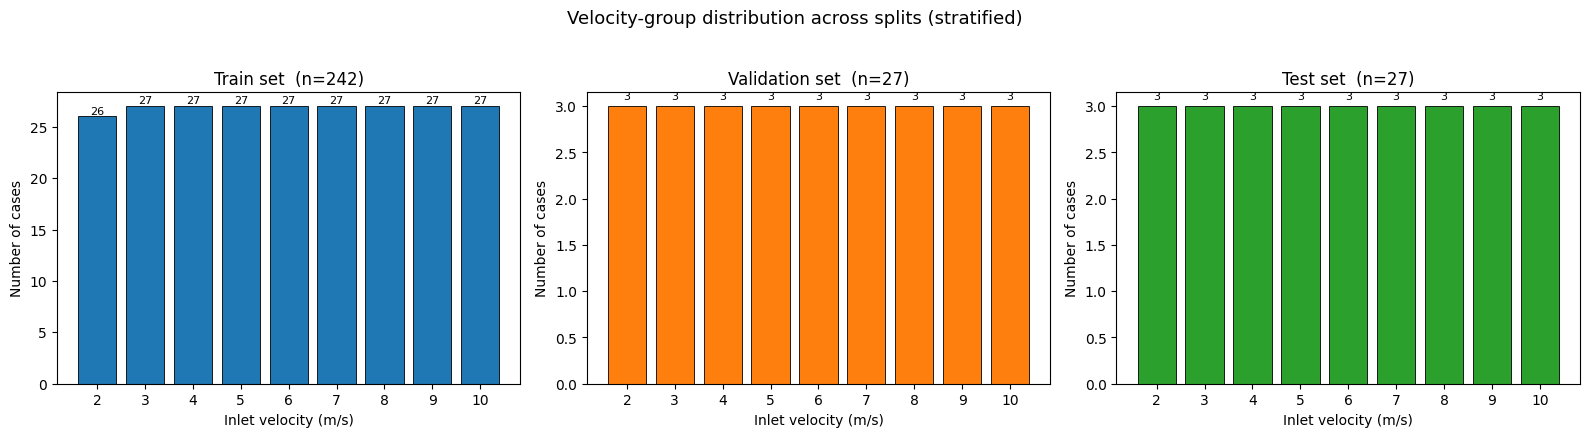

In [109]:
# ── Per-set velocity-group distributions ──────────────────────────────────────
all_vels = sorted({velmap[c] for c in valid_ids})
splits = {"Train": train_ids, "Validation": val_ids, "Test": test_ids}
colors = {"Train": "#1f77b4", "Validation": "#ff7f0e", "Test": "#2ca02c"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=False)
for ax, (name, ids) in zip(axes, splits.items()):
    counts = [sum(1 for c in ids if velmap[c] == v) for v in all_vels]
    ax.bar([str(int(v)) for v in all_vels], counts, color=colors[name], edgecolor="black", lw=0.6)
    ax.set_title(f"{name} set  (n={len(ids)})", fontsize=12)
    ax.set_xlabel("Inlet velocity (m/s)")
    ax.set_ylabel("Number of cases")
    for i, c in enumerate(counts):
        ax.text(i, c + 0.05, str(c), ha="center", va="bottom", fontsize=8)
fig.suptitle("Velocity-group distribution across splits (stratified)", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

---
# Section 9 — Scaling and Standardization  *(Pipeline stage 3.5)*

## What we scale, and why

Neural networks train best when input channels live on comparable numeric scales — otherwise a
large-magnitude channel (e.g. velocity in m/s) dominates the gradient and slows convergence. **We
fit every scaler on the training set only** and apply those same parameters to validation and test.
This prevents *data leakage*: information from val/test must never influence the transformation.

Two different strategies, chosen per channel based on what the channel *means*:

| Channel | Method | Why |
|---------|--------|-----|
| **SDF** | **Standardization** (z-score) | Continuous, roughly symmetric distance values → center to mean 0, unit variance. |
| **Inlet velocity** | **Standardization** (z-score) | Continuous physical magnitude → z-score keeps regimes comparable. |
| **Flow region** | **Normalization** (min–max) | **Categorical/ordinal labels** {1..6}. Standardizing categories is meaningless — it would distort label identity. Min–max keeps them in [0, 1] while preserving their order/identity. |

We use **scikit-learn** utilities (`StandardScaler`, `MinMaxScaler`) so the saved parameters are
standard and easy to reuse at inference time.

In [110]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ── Fit scalers on TRAINING data only (no leakage) ────────────────────────────
# We collect the raw channel values from every training case first, then fit
# the scalers on all of them at once. Fitting on training data only is critical:
# if we included val/test values here, the scaler would "know" something about
# those cases before the model ever sees them — that is called data leakage and
# it makes evaluation results unreliable.
sdf_vals, vel_vals, region_vals = [], [], []
total = len(train_ids)
for i, cid in enumerate(train_ids, 1):
    # build_input_channels returns a (3, H, W) array — one slice per channel.
    X = build_input_channels(cid)
    # .ravel() flattens the 2-D channel into a 1-D list of pixel values so we
    # can pool all pixels from all cases into a single array before fitting.
    sdf_vals.append(X[0].ravel())
    vel_vals.append(X[1].ravel())
    region_vals.append(X[2].ravel())
    print(f"\rFitting scalers: {i}/{total}", end="", flush=True)
print()

# Stack all per-case pixel lists into one big array.
# reshape(-1, 1) turns the flat list into a column vector because sklearn
# scalers expect input shape (n_samples, n_features).
sdf_vals    = np.concatenate(sdf_vals).reshape(-1, 1)
vel_vals    = np.concatenate(vel_vals).reshape(-1, 1)
region_vals = np.concatenate(region_vals).reshape(-1, 1)

# Fit a StandardScaler (z-score) on SDF and inlet-velocity channels.
# Z-score transforms each value as: (value - mean) / std
# This centers the data at 0 with a spread of 1, which is the ideal input
# range for neural network weight updates.
sdf_scaler = StandardScaler().fit(sdf_vals)
vel_scaler = StandardScaler().fit(vel_vals)

# Fit a MinMaxScaler on the flow-region channel.
# The region channel holds integer class labels {1..6}, not continuous measurements.
# Z-scoring class labels is meaningless (the "mean region" has no physical meaning).
# Min-max scaling maps them to [0, 1] while keeping their relative order intact.
region_scaler = MinMaxScaler().fit(region_vals)

print("Fitted scalers (training statistics):")
print(f"  SDF       : mean={sdf_scaler.mean_[0]:.5f}  std={sdf_scaler.scale_[0]:.5f}")
print(f"  Inlet vel : mean={vel_scaler.mean_[0]:.5f}  std={vel_scaler.scale_[0]:.5f}")
print(f"  Region    : min={region_scaler.data_min_[0]:.1f}  max={region_scaler.data_max_[0]:.1f}")

def apply_scaling(X):
    """Apply the fitted (training) scalers to a (3, H, W) input tensor."""
    H, W = X.shape[1], X.shape[2]
    out = np.empty_like(X, dtype=np.float32)
    # reshape(-1, 1) and reshape(H, W) convert between the flat column format
    # that sklearn expects and the 2-D grid format the model expects.
    out[0] = sdf_scaler.transform(X[0].reshape(-1, 1)).reshape(H, W)
    out[1] = vel_scaler.transform(X[1].reshape(-1, 1)).reshape(H, W)
    out[2] = region_scaler.transform(X[2].reshape(-1, 1)).reshape(H, W)
    return out

Fitting scalers: 242/242
Fitted scalers (training statistics):
  SDF       : mean=0.23926  std=0.11444
  Inlet vel : mean=6.01653  std=2.57446
  Region    : min=1.0  max=5.0


## Saving statistics for inference

A surrogate model deployed later must apply the **exact same** transformation to new inputs. We
therefore persist all scaler parameters (means, standard deviations, min/max) to the `models/`
folder — both as a human-readable JSON and as a pickled scaler bundle.

In [111]:
import json, pickle
N_REGIONS = 5
scaling_stats = {
    "sdf":    {"method": "standardize", "mean": float(sdf_scaler.mean_[0]),  "std": float(sdf_scaler.scale_[0])},
    "inlet_velocity": {"method": "standardize", "mean": float(vel_scaler.mean_[0]), "std": float(vel_scaler.scale_[0])},
    "flow_region": {"method": "minmax", "min": float(region_scaler.data_min_[0]), "max": float(region_scaler.data_max_[0])},
    "img_size": IMG_SIZE, "n_regions": N_REGIONS, "seed": RANDOM_SEED,
    "fitted_on": "training set only", "n_train_cases": len(train_ids),
}
(CONFIG["models"] / "scaling_stats.json").write_text(json.dumps(scaling_stats, indent=2))

with open(CONFIG["models"] / "scalers.pkl", "wb") as f:
    pickle.dump({"sdf": sdf_scaler, "inlet_velocity": vel_scaler, "flow_region": region_scaler}, f)

print("Saved:")
print("  ", CONFIG["models"] / "scaling_stats.json")
print("  ", CONFIG["models"] / "scalers.pkl")
print("\n" + json.dumps(scaling_stats, indent=2))

Saved:
   /content/cfd_workshop/models/scaling_stats.json
   /content/cfd_workshop/models/scalers.pkl

{
  "sdf": {
    "method": "standardize",
    "mean": 0.23926232409926995,
    "std": 0.11444017083889084
  },
  "inlet_velocity": {
    "method": "standardize",
    "mean": 6.016528925619835,
    "std": 2.5744564413039814
  },
  "flow_region": {
    "method": "minmax",
    "min": 1.0,
    "max": 5.0
  },
  "img_size": 128,
  "n_regions": 5,
  "seed": 42,
  "fitted_on": "training set only",
  "n_train_cases": 242
}


---
# Section 10 — End-to-End Processing Pipeline

Finally we tie everything together into one reusable function that takes a list of case IDs and:

1. Loads raw inputs (geometry)
2. Builds the three engineered channels (SDF, inlet velocity, flow region)
3. Applies the **training-derived** scaling
4. Saves processed input tensor as `.npy`
5. Converts the target CSV to a velocity grid and saves it as `.npy`

**Data augmentation** is integrated as well, **applied only to the training set** (after scaling):
each training case additionally produces a horizontal- and a vertical-flip copy, with the input
tensor and target flipped identically. Validation and test cases are saved without augmentation.

Output layout:

```text
processed/
├── train/
│   ├── inputs/
│   │   ├── case_<id>.npy          # (3, 128, 128) float32, scaled
│   │   ├── case_<id>_hflip.npy    # horizontal-flip copy
│   │   └── case_<id>_vflip.npy    # vertical-flip copy
│   └── targets/
│       ├── case_<id>.npy          # (128, 128) float32, raw m/s
│       ├── case_<id>_hflip.npy
│       └── case_<id>_vflip.npy
├── val/
│   ├── inputs/   → case_<id>.npy  (no augmentation)
│   └── targets/  → case_<id>.npy
└── test/
    ├── inputs/   → case_<id>.npy  (no augmentation)
    └── targets/  → case_<id>.npy
```

Each split lives in its own folder — no filename-based filtering needed at training time.</cell_type>

In [112]:
def target_csv_to_npy(csv_path, npy_path, size=IMG_SIZE):
    """Convert a raw target CSV into a (size, size) float32 velocity grid and save as .npy.
    Returns the grid so the caller can reuse it for augmentation without re-reading the CSV."""
    grid = load_target_grid(csv_path, size)
    np.save(npy_path, grid)
    return grid


def run_pipeline(case_ids, split_name, augment=False):
    """End-to-end preprocessing for one split (train / val / test).

    Saves all outputs under processed/<split_name>/inputs/ and processed/<split_name>/targets/
    so each split has its own folder — no filename filtering needed at training time.

    If augment=True (training set only), also saves hflip and vflip copies of both
    input and target with the same flip applied to keep them spatially aligned."""

    # Each split gets its own inputs/ and targets/ sub-folder.
    in_dir  = CONFIG["processed"] / split_name / "inputs"
    out_dir = CONFIG["processed"] / split_name / "targets"
    in_dir.mkdir(parents=True, exist_ok=True)
    out_dir.mkdir(parents=True, exist_ok=True)

    aug_note = "  (+ h/v-flip augmentation)" if augment else ""
    print(f"=== Pipeline [{split_name}] — {len(case_ids)} cases{aug_note} ===")

    n_saved, n_aug = 0, 0
    total = len(case_ids)

    for i, cid in enumerate(case_ids, 1):
        # Step 1: Load the raw geometry image.
        geo = load_input_image(input_ids[cid])

        # Steps 2-4: Build the three engineered channels and apply scaling.
        X_scaled = apply_scaling(build_input_channels(cid, geo=geo))

        # Step 5: Save the scaled input tensor.
        np.save(in_dir / f"case_{cid}.npy", X_scaled.astype(np.float32))

        # Step 6: Convert the target CSV to a velocity grid and save as .npy.
        # Returns the grid so augmentation below can reuse it without re-reading the file.
        y_grid = target_csv_to_npy(target_ids[cid], out_dir / f"case_{cid}.npy")
        n_saved += 1

        # Step 7 (training only): Save hflip and vflip copies.
        # Input and target are flipped with the same axis so they stay aligned.
        if augment:
            for suffix, (Xa, ya) in (("hflip", augment_hflip(X_scaled, y_grid)),
                                     ("vflip", augment_vflip(X_scaled, y_grid))):
                np.save(in_dir  / f"case_{cid}_{suffix}.npy", Xa.astype(np.float32))
                np.save(out_dir / f"case_{cid}_{suffix}.npy", ya.astype(np.float32))
                n_aug += 1

        print(f"\rProcessing [{split_name}]: {i}/{total}", end="", flush=True)

    print()
    extra = f", {n_aug} augmented" if augment else ""
    print(f"Done [{split_name}]: {n_saved} base{extra} → {n_saved + n_aug} total files saved.")
    return n_saved + n_aug

print("target_csv_to_npy() and run_pipeline() defined.")

target_csv_to_npy() and run_pipeline() defined.


### Run the full pipeline

We process all three splits. (Inputs are scaled with the shared training-set scalers; targets are
copied unchanged so a training notebook can normalize the *output* however it prefers.) The
`[step/total]` banner below mirrors the eight pipeline steps.

In [113]:
print("[1/8] Loading data ...")
print("[2/8] Checking CSV integrity ...")
print("[3/8] Validating cases ...")
print("[4/8] Computing SDF channels ...")
print("[5/8] Building inlet-velocity channels ...")
print("[6/8] Labeling flow regions ...")
print("[7/8] Applying train-derived scaling ...")
print("[8/8] Saving processed dataset ...\n")

total = 0
for name, ids in [("train", train_ids), ("val", val_ids), ("test", test_ids)]:
    total += run_pipeline(ids, split_name=name, augment=(name == "train"))

print(f"\nAll splits processed. {total} cases written to {CONFIG['processed']}")

[1/8] Loading data ...
[2/8] Checking CSV integrity ...
[3/8] Validating cases ...
[4/8] Computing SDF channels ...
[5/8] Building inlet-velocity channels ...
[6/8] Labeling flow regions ...
[7/8] Applying train-derived scaling ...
[8/8] Saving processed dataset ...

=== Pipeline [train] — 242 cases  (+ h/v-flip augmentation) ===
Processing [train]: 242/242
Done [train]: 242 base, 484 augmented → 726 total files saved.
=== Pipeline [val] — 27 cases ===
Processing [val]: 27/27
Done [val]: 27 base → 27 total files saved.
=== Pipeline [test] — 27 cases ===
Processing [test]: 27/27
Done [test]: 27 base → 27 total files saved.

All splits processed. 780 cases written to /content/cfd_workshop/processed


---
# Verification

A final sanity check: reload a saved file, confirm its shape / dtype / value ranges, and visualize
a scaled input next to its target. If this looks right, your dataset is **training-ready**.

Dataset summary — all files are .npy, split into separate folders:
  processed/train/  :  242 original  +  484 augmented  =  726 total
  processed/val/    :  27
  processed/test/   :  27
  ───────────────────────────────────────────────────────
  Grand total       :  780 input/target pairs

Sanity checks passed.

Sample: case_1.npy  (inlet 2 m/s)
  Input  shape : (3, 128, 128)  dtype : float32
  Ch1 SDF    (scaled) : [-2.139, 2.495]  mean -0.001
  Ch2 InletV (scaled) : [-1.560, -1.560]
  Ch3 Region (scaled) : [0.000, 1.000]
  Target shape : (128, 128)  dtype : float32  range : [0.07, 2.37] m/s

Flip check (hflip, case 100): flipped original matches saved file? True


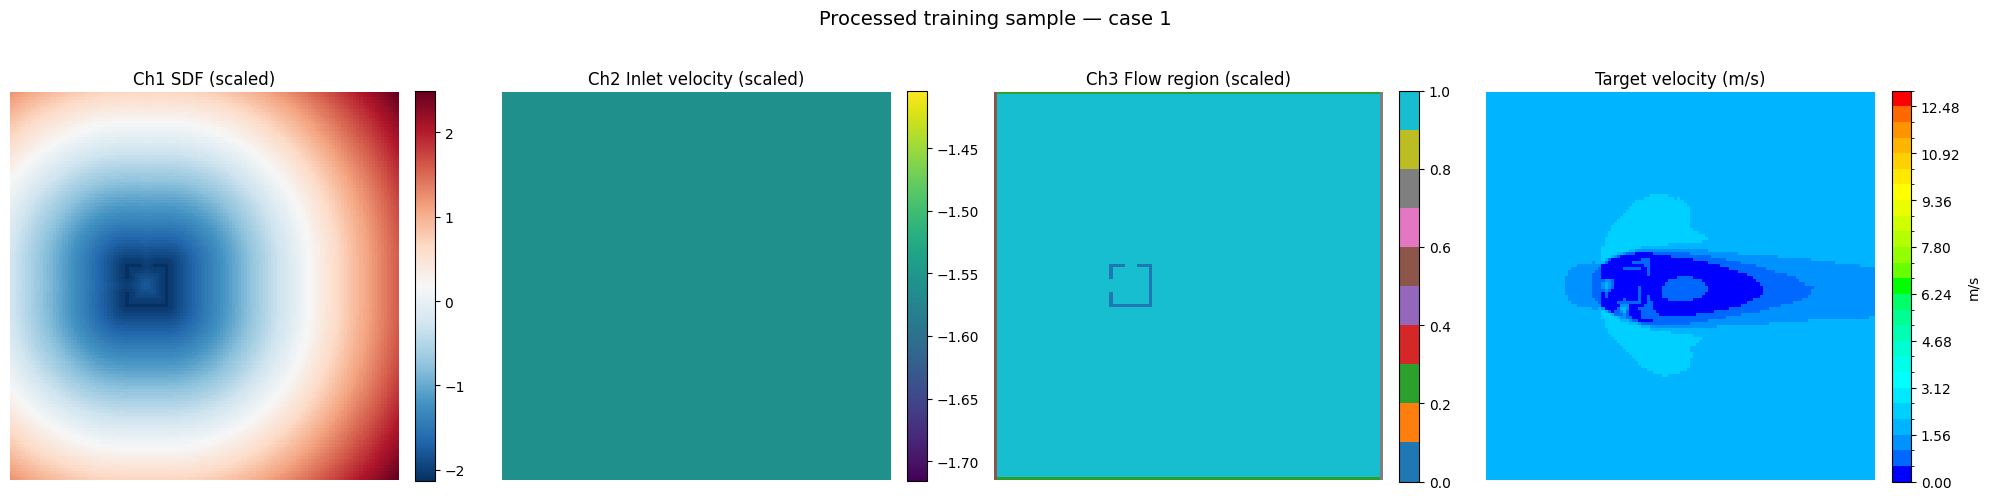


Preprocessing complete — dataset is training-ready!


In [114]:
# ── Verify the saved processed dataset ────────────────────────────────────────
def count_split(split_name):
    """Return (base_count, aug_count) for a given split folder."""
    files = sorted((CONFIG["processed"] / split_name / "inputs").glob("*.npy"))
    aug   = [f for f in files if "_hflip" in f.stem or "_vflip" in f.stem]
    base  = [f for f in files if f not in aug]
    return base, aug

train_base, train_aug = count_split("train")
val_base,   val_aug   = count_split("val")
test_base,  test_aug  = count_split("test")

n_train = len(train_base) + len(train_aug)
n_val   = len(val_base)
n_test  = len(test_base)
n_total = n_train + n_val + n_test

print("Dataset summary — all files are .npy, split into separate folders:")
print(f"  processed/train/  :  {len(train_base)} original  +  {len(train_aug)} augmented  =  {n_train} total")
print(f"  processed/val/    :  {n_val}")
print(f"  processed/test/   :  {n_test}")
print(f"  {'─'*55}")
print(f"  Grand total       :  {n_total} input/target pairs")

# Sanity check: expected counts from the split lists.
assert len(train_base) == len(train_ids),      "train base count mismatch"
assert len(train_aug)  == len(train_ids) * 2,  "train augmented count mismatch"
assert n_val  == len(val_ids),                 "val count mismatch"
assert n_test == len(test_ids),                "test count mismatch"
print("\nSanity checks passed.")

# ── Inspect one training sample ───────────────────────────────────────────────
sample = train_base[0]
Xv  = np.load(sample)
cid = int(sample.stem.split("_")[1])
print(f"\nSample: {sample.name}  (inlet {velmap[cid]:.0f} m/s)")
print(f"  Input  shape : {Xv.shape}  dtype : {Xv.dtype}")
print(f"  Ch1 SDF    (scaled) : [{Xv[0].min():.3f}, {Xv[0].max():.3f}]  mean {Xv[0].mean():.3f}")
print(f"  Ch2 InletV (scaled) : [{Xv[1].min():.3f}, {Xv[1].max():.3f}]")
print(f"  Ch3 Region (scaled) : [{Xv[2].min():.3f}, {Xv[2].max():.3f}]")

target_sample = np.load(CONFIG["processed"] / "train" / "targets" / f"case_{cid}.npy")
print(f"  Target shape : {target_sample.shape}  dtype : {target_sample.dtype}  "
      f"range : [{target_sample.min():.2f}, {target_sample.max():.2f}] m/s")

# ── Confirm a flip copy matches the flipped original ─────────────────────────
f_aug   = train_aug[0]
base_id = int(f_aug.stem.split("_")[1])
kind    = "hflip" if "_hflip" in f_aug.stem else "vflip"
axis    = -1 if kind == "hflip" else -2
orig    = np.load(CONFIG["processed"] / "train" / "inputs" / f"case_{base_id}.npy")
flipped = np.load(f_aug)
ok = np.allclose(np.flip(orig, axis=axis), flipped)
print(f"\nFlip check ({kind}, case {base_id}): flipped original matches saved file? {ok}")

# ── Visualize one input + its target ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for k, (title, cmap) in enumerate(zip(
        ["Ch1 SDF (scaled)", "Ch2 Inlet velocity (scaled)", "Ch3 Flow region (scaled)"],
        ["RdBu_r", "viridis", "tab10"])):
    im = axes[k].imshow(Xv[k], origin="lower", cmap=cmap)
    axes[k].set_title(title); axes[k].axis("off")
    plt.colorbar(im, ax=axes[k], fraction=0.046, pad=0.04)

im = axes[3].imshow(target_sample, origin="lower", cmap=velocity_cmap, norm=velocity_norm)
axes[3].set_title("Target velocity (m/s)"); axes[3].axis("off")
plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04, label="m/s")
fig.suptitle(f"Processed training sample — case {cid}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nPreprocessing complete — dataset is training-ready!")

---
## Summary

You have walked the full preprocessing pipeline:

1. **3.1 Data Cleaning** — scanned every target CSV for NaN values with `validate_target_csv`
   and confirmed all 296 files are clean. Any NaN rows encountered during loading are dropped
   automatically by `load_target_grid`.

2. **3.2 Architecture Selection** — justified a U-Net for dense, geometry-driven image-to-image
   regression: encoder–decoder structure with skip connections preserves spatial alignment while
   capturing both local geometry detail and global flow patterns.

3. **3.3 Feature Engineering** — built three physics-aware input channels per case:
   - **SDF** — signed distance to the nearest wall, normalized by the grid diagonal.
   - **Inlet velocity** — the case's wind speed broadcast across the full grid.
   - **Flow region** — per-pixel boundary-condition labels {1..5}.

4. **3.4 Train / Val / Test Split** — stratified 80 / 10 / 10 split by inlet-velocity group
   (2–10 m/s) with a fixed seed. The split manifest is saved to `models/split_manifest.json`
   for reproducibility.

5. **3.5 Scaling / Normalization** — fitted scalers on the **training set only** (no leakage):
   `StandardScaler` for SDF and inlet velocity, `MinMaxScaler` for the region labels.
   Parameters saved to `models/scaling_stats.json` and `models/scalers.pkl` for inference.

6. **Data augmentation** — horizontal and vertical flips applied to the **training set only**,
   after scaling, with inputs and targets flipped identically (3× the original training data).

7. **Output structure** — all processed files are uniform `.npy` arrays saved into
   split-specific folders. Re-running the directory-creation cell wipes and recreates the
   folder tree cleanly.

```text
processed/
├── train/    →  242 original  +  484 augmented  =  726 input/target pairs
├── val/      →   27 input/target pairs
└── test/     →   27 input/target pairs
                ─────────────────────────────
                 780 total  (inputs and targets both .npy)
```

Your `processed/` folder and `models/` statistics are exactly what a training notebook needs —
load inputs with `np.load`, load targets with `np.load`, apply the saved scalers at inference.

**Reference:** Vandewiel, Eneyew, Awol, Capretz & Bitsuamlak (2025), *Approximating CFD simulations
of natural ventilation: A deep surrogate model with spatial attention mechanism*, Journal of
Building Engineering 105, 112425.
Updated. The summary now accurately reflects the current state of the notebook:

Points to .npy targets instead of CSVs
Documents the split-specific folder structure with exact counts (726 train / 27 val / 27 test = 780 total)
Mentions the fresh-wipe behaviour of the directory creation cell
Notes the validate_target_csv is a NaN-only check (not PASS/WARN/FAIL)
Ends with a one-liner on how to consume the output in a training notebook
